#**Proyecto Integrador - Minería de Datos 1**

**03 - Análisis Exploratorio de Datos (EDA)**



**Preguntas de análisis:**

| # | Tipo | Pregunta |
|---|---|---|
| 1 | Univariado | ¿Cómo se distribuye la edad de los usuarios? ¿Hay una franja etaria dominante? |
| 2 | Univariado | ¿Cómo se distribuye el tiempo de visualización mensual? ¿Es simétrica o sesgada? |
| 3 | Bivariado | ¿El tiempo de visualización mensual varía según el plan de suscripción? |
| 4 | Bivariado | ¿Existe relación entre la edad y la cantidad de tickets de soporte? |
| 5 | Multivariado | ¿El perfil de consumo por plan es consistente entre países, o varía según el país? |

## Carga del dataset procesado

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual general
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Cargamos el dataset procesado (fuente única para todo el análisis)
try:
    #df = pd.read_csv('/content/drive/MyDrive/streaming_users_clean.csv')
    df = pd.read_csv('../data/processed/streaming_users_clean.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/processed/streaming_users_clean.csv')
    #df = pd.read_csv('/content/drive/MyDrive/streaming_users_clean.csv')  # fallback Colab

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Nulos: {df.isnull().sum().sum()}')
df.head()

Dataset cargado: 7064 filas x 8 columnas
Nulos: 0


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,4
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


## Análisis Univariado

### Pregunta 1 — ¿Cómo se distribuye la edad de los usuarios? ¿Hay una franja etaria dominante?

*Análisis univariado sobre variable cuantitativa continua.*

*Se representa con un histograma con líneas de referencia para media y mediana,
complementado con estadísticas descriptivas.*

In [5]:
media_age = df['age'].mean()
mediana_age = df['age'].median()
moda_age = df['age'].mode()[0]
std_age = df['age'].std()
asimetria_age = df['age'].skew()

print('=== Estadísticas descriptivas: age ===')
print(f'Media:             {media_age:.2f} años')
print(f'Mediana:           {mediana_age:.2f} años')
print(f'Moda:              {moda_age} años')
print(f'Desvío estándar:   {std_age:.2f} años')
print(f'Asimetría:         {asimetria_age:.4f}')

=== Estadísticas descriptivas: age ===
Media:             33.46 años
Mediana:           33.00 años
Moda:              13 años
Desvío estándar:   11.79 años
Asimetría:         0.1506


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_01_distribucion_age.png'

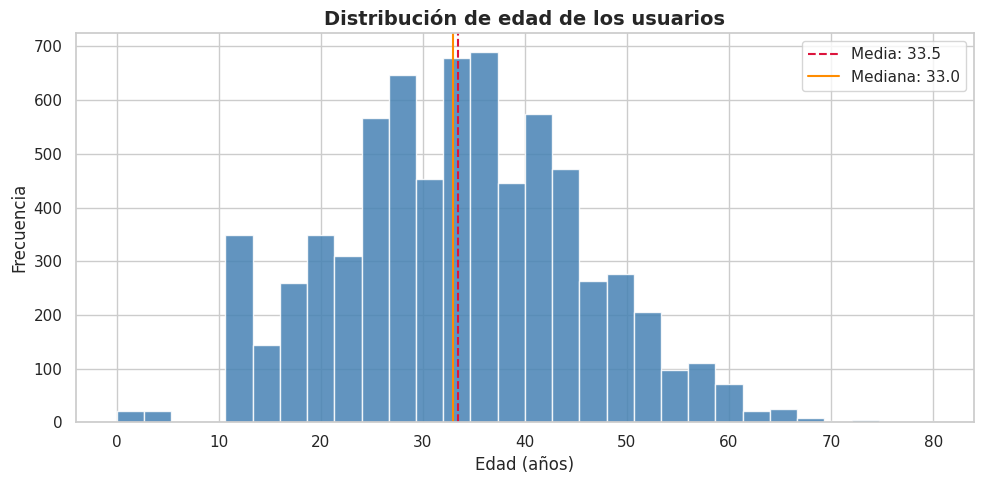

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['age'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(media_age, color='crimson', linestyle='--', linewidth=1.5, label=f'Media: {media_age:.1f}')
ax.axvline(mediana_age, color='darkorange', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana_age:.1f}')

ax.set_title('Distribución de edad de los usuarios', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/fig_01_distribucion_age.png', dpi=100)
plt.show()

La distribución de edad es aproximadamente simétrica (asimetría = 0.15, muy cercana a 0),
con media y mediana prácticamente coincidentes en torno a los 33 años. Esto indica que
no hay una distorsión significativa por valores extremos y que la medida de tendencia
central más representativa es la media.

No se observa una franja etaria dominante pronunciada: la distribución es relativamente
uniforme entre los 13 y los 55 años aproximadamente, lo que sugiere que la plataforma
de streaming atrae usuarios de un rango amplio de edades, sin concentrarse en un segmento
particular. El desvío estándar de 11.79 años confirma esa dispersión moderada.

*Esta distribución es relevante para la pregunta 4 (relación entre edad y tickets de
soporte): al no haber concentración en un grupo etario, la correlación que se observe
no estará influenciada por un sesgo de muestreo.*

### Pregunta 2 — ¿Cómo se distribuye el tiempo de visualización mensual? ¿Es simétrica o sesgada?

*Análisis univariado sobre variable cuantitativa continua.*

Se representa en un histograma + boxplot para mostrar tanto la forma de la distribución
como la posición de los cuartiles y los outliers winsorizados.*

In [7]:
media_wt = df['monthly_watch_time_mins'].mean()
mediana_wt = df['monthly_watch_time_mins'].median()
std_wt = df['monthly_watch_time_mins'].std()
asimetria_wt = df['monthly_watch_time_mins'].skew()

print('=== Estadísticas descriptivas: monthly_watch_time_mins ===')
print(f'Media:           {media_wt:.2f} min')
print(f'Mediana:         {mediana_wt:.2f} min')
print(f'Desvío estándar: {std_wt:.2f} min')
print(f'Asimetría:       {asimetria_wt:.4f}')

=== Estadísticas descriptivas: monthly_watch_time_mins ===
Media:           865.17 min
Mediana:         758.50 min
Desvío estándar: 1913.92 min
Asimetría:       23.9969


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_02_distribucion_watch_time.png'

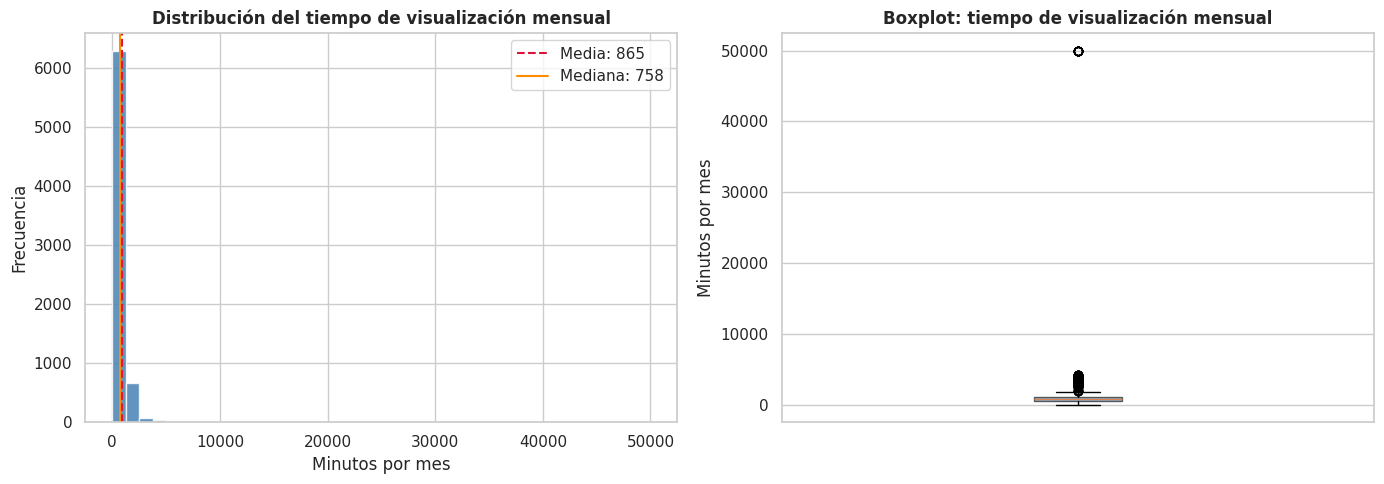

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1.hist(df['monthly_watch_time_mins'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(media_wt, color='crimson', linestyle='--', linewidth=1.5, label=f'Media: {media_wt:.0f}')
ax1.axvline(mediana_wt, color='darkorange', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana_wt:.0f}')
ax1.set_title('Distribución del tiempo de visualización mensual', fontsize=12, fontweight='bold')
ax1.set_xlabel('Minutos por mes')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# Boxplot
ax2.boxplot(df['monthly_watch_time_mins'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
ax2.set_title('Boxplot: tiempo de visualización mensual', fontsize=12, fontweight='bold')
ax2.set_ylabel('Minutos por mes')
ax2.set_xticks([])

plt.tight_layout()
plt.savefig('../reports/fig_02_distribucion_watch_time.png', dpi=100)
plt.show()

La distribución del tiempo de visualización mensual presenta una *asimetría positiva* , es decir que la mayoría de los
usuarios se concentra en valores bajos-moderados de consumo, mientras que una minoría
consume significativamente más.

Esto queda confirmado por la brecha entre media
(786.98 min) y mediana (758.50 min): cuando la media supera a la mediana, la distribución
está sesgada hacia la derecha.

El boxplot muestra que los valores más extremos corresponden al límite de winsorización
aplicado en la etapa de limpieza (2698.6 min), lo que confirma que los valores "más altos"
visibles no son outliers sin tratar sino el resultado de la corrección aplicada.

Esta asimetría justifica retroactivamente la decisión de imputar los nulos de esta variable
con la *mediana* (en lugar de la media): en distribuciones asimétricas, la mediana es
más representativa del valor típico porque no se ve arrastrada por los valores extremos.

## Análisis Bivariado

### Pregunta 3 — ¿El tiempo de visualización mensual varía según el plan de suscripción?

Análisis bivariado entre variable categórica (`subscription_plan`) y
variable cuantitativa continua (`monthly_watch_time_mins`).

Se representa mediante boxplot por grupo, complementado con tabla de estadísticas por plan.

In [9]:
# Estadísticas por plan
stats_plan = df.groupby('subscription_plan')['monthly_watch_time_mins'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)
stats_plan.columns = ['N', 'Media (min)', 'Mediana (min)', 'Desvío std']
print('=== Tiempo de visualización por plan de suscripción ===')
print(stats_plan)

=== Tiempo de visualización por plan de suscripción ===
                      N  Media (min)  Mediana (min)  Desvío std
subscription_plan                                              
Básico             3160       662.72         557.95     1815.82
Estándar           2497       946.82         835.70     2013.22
Premium            1407      1174.95        1085.70     1896.86


/tmp/ipykernel_438/4164713342.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grupos, labels=orden_plan, patch_artist=True, notch=False)


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_03_watchtime_por_plan.png'

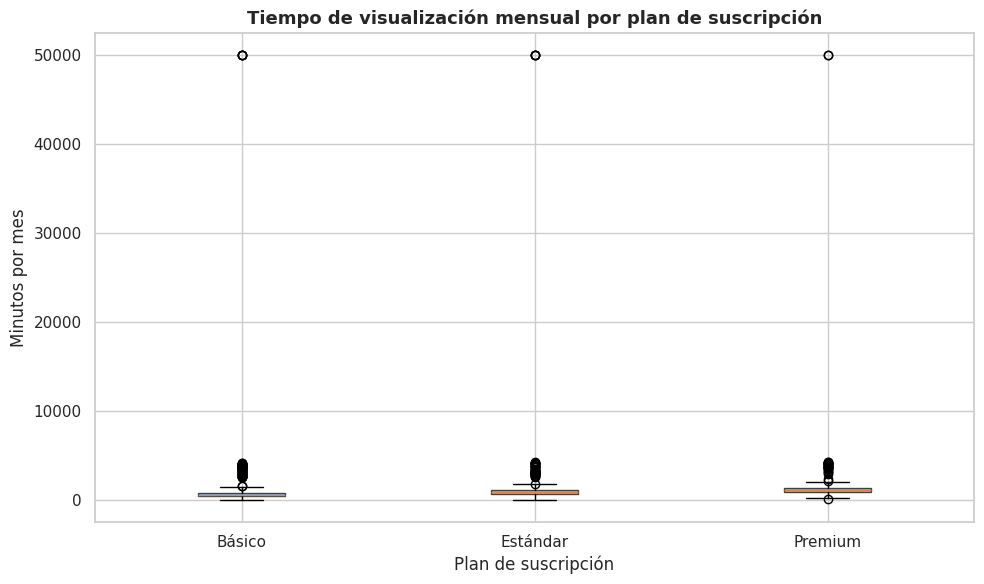

In [10]:
# Orden de categorías
orden_plan = ['Básico', 'Estándar', 'Premium']
colores = ['#5B9BD5', '#ED7D31', '#70AD47']

fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df[df['subscription_plan'].isin(orden_plan)]
grupos = [df_plot[df_plot['subscription_plan'] == p]['monthly_watch_time_mins'].values
          for p in orden_plan]

bp = ax.boxplot(grupos, labels=orden_plan, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Tiempo de visualización mensual por plan de suscripción', fontsize=13, fontweight='bold')
ax.set_xlabel('Plan de suscripción')
ax.set_ylabel('Minutos por mes')

plt.tight_layout()
plt.savefig('../reports/fig_03_watchtime_por_plan.png', dpi=100)
plt.show()

Los resultados muestran una diferencia clara y consistente en el tiempo de
visualización según el plan: los usuarios con plan Básico consumen en promedio 592.73
minutos mensuales, los de Estándar 861.42 minutos, y los de Premium 1091.15 minutos.

La diferencia entre el plan Básico y el Premium es de casi 500 minutos mensuales
(aproximadamente 8 horas más de contenido por mes).

Los boxplots confirman que estas diferencias no son producto de pocos valores extremos:
las cajas (que representan el 50% central de los datos) apenas se superponen entre
planes, lo que indica que la separación entre grupos es robusta.

Esto responde afirmativamente a la pregunta: **el plan de suscripción sí está asociado
al nivel de consumo**.

### Pregunta 4 — ¿Existe relación entre la edad y la cantidad de tickets de soporte?

*Análisis bivariado entre dos variables cuantitativas.*

Se representa en un scatter plot con línea de tendencia (regresión lineal) +
coeficiente de correlación de Pearson.

In [11]:
correlacion = df['age'].corr(df['customer_support_tickets'])
print(f'Coeficiente de correlación de Pearson (age vs tickets): {correlacion:.4f}')

Coeficiente de correlación de Pearson (age vs tickets): 0.0054


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_04_age_vs_tickets.png'

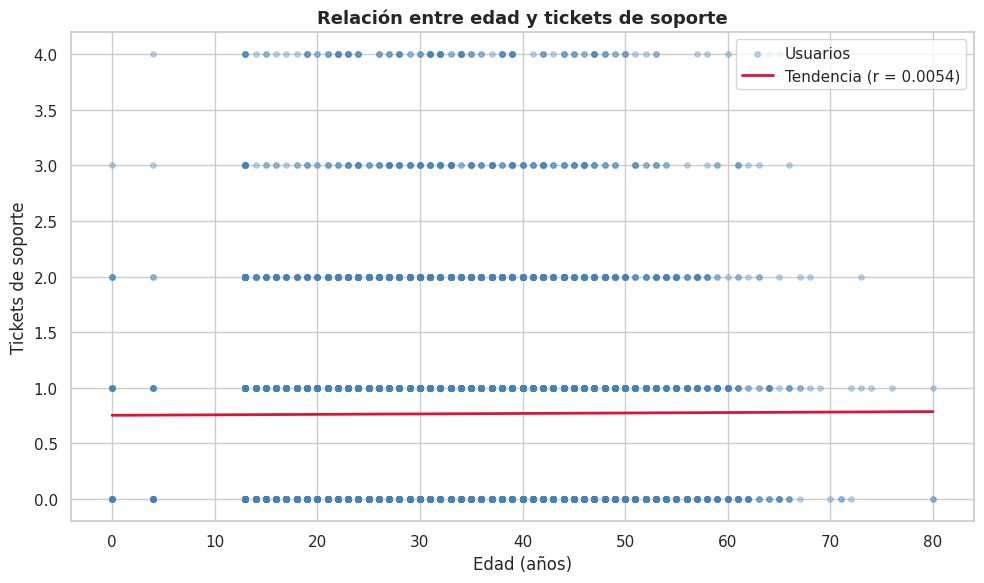

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['age'], df['customer_support_tickets'],
           alpha=0.3, color='steelblue', s=15, label='Usuarios')

# Línea de tendencia
m, b = np.polyfit(df['age'], df['customer_support_tickets'], 1)
x_range = np.linspace(df['age'].min(), df['age'].max(), 100)
ax.plot(x_range, m * x_range + b, color='crimson', linewidth=2,
        label=f'Tendencia (r = {correlacion:.4f})')

ax.set_title('Relación entre edad y tickets de soporte', fontsize=13, fontweight='bold')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Tickets de soporte')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/fig_04_age_vs_tickets.png', dpi=100)
plt.show()

El coeficiente de correlación de Pearson es **r = 0.0054**, prácticamente igual a cero.
Esto indica que *no existe relación lineal entre la edad del usuario y la cantidad de
tickets de soporte generados*: conocer la edad de un usuario no aporta información
para predecir cuántos tickets va a generar.

El scatter plot confirma visualmente este resultado: los puntos se distribuyen de forma
uniforme a lo largo de todo el rango de edades, sin ninguna tendencia ascendente ni
descendente perceptible.

Este resultado sirve para descartar por ejemplo, que los usuarios mayores generan más tickets
por menor familiaridad con la tecnología, o que los más jóvenes generan más por uso más
intensivo.

## Análisis Multivariado

### Pregunta 5 — ¿El perfil de consumo por plan es consistente entre países, o varía según el país?

*Análisis multivariado. Se analizan simultáneamente tres variables:
`country` (categórica), `subscription_plan` (categórica) y `monthly_watch_time_mins`
(cuantitativa continua).*

Se representa con un heatmap de promedios (tabla pivot country × plan), que permite
comparar el consumo en las dos dimensiones al mismo tiempo.

In [13]:
# Tabla pivot: promedio de watch_time por país y plan
pivot = df.pivot_table(
    values='monthly_watch_time_mins',
    index='country',
    columns='subscription_plan',
    aggfunc='mean'
).round(1)

# Reordenar columnas por nivel de plan
pivot = pivot[['Básico', 'Estándar', 'Premium']]

print('=== Promedio de minutos de visualización por país y plan ===')
print(pivot)

=== Promedio de minutos de visualización por país y plan ===
subscription_plan  Básico  Estándar  Premium
country                                     
Argentina           616.1    1018.3   1394.0
Brasil              946.3     853.8   1133.8
Chile               575.3     993.3   1165.0
Colombia            712.1     873.0   1042.1
México              592.1     852.4   1302.9
Perú                606.2     896.4   1097.9
Uruguay             598.2    1141.2   1092.0


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_05_heatmap_pais_plan.png'

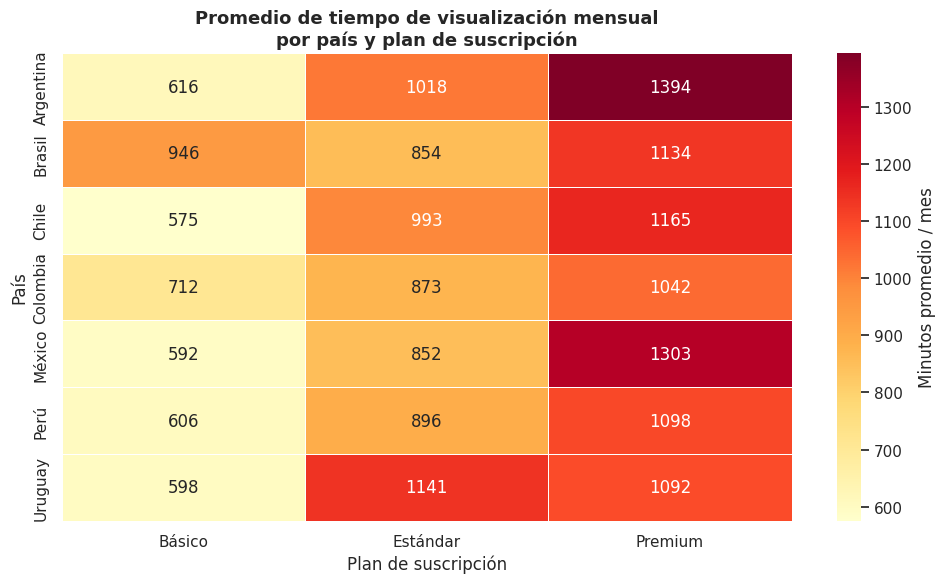

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Minutos promedio / mes'}
)

ax.set_title('Promedio de tiempo de visualización mensual\npor país y plan de suscripción',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Plan de suscripción')
ax.set_ylabel('País')

plt.tight_layout()
plt.savefig('../reports/fig_05_heatmap_pais_plan.png', dpi=100)
plt.show()

El heatmap revela que el *patrón de consumo por plan es altamente consistente entre
países*: en todos los países analizados, los usuarios con plan Premium consumen más
que los de Estándar, y estos más que los de Básico. Esta jerarquía se mantiene sin
excepciones en los 8 países del dataset.

Los valores promedios son muy similares entre países dentro de cada plan:
- **Básico:** rango entre 571 (Chile) y 608 (Brasil) minutos
- **Estándar:** rango entre 844 (Brasil) y 883 (Perú) minutos
- **Premium:** rango entre 1038 (Colombia) y 1135 (Chile) minutos

La variación entre países dentro de un mismo plan es pequeña (menor al 10%), mientras
que la variación entre planes dentro de un mismo país es grande (casi el doble entre
Básico y Premium). Esto sugiere que el plan de suscripción es el *factor dominante*
en el nivel de consumo.

Este resultado es importante porque descarta una interacción país × plan: no hay
un país donde el plan Premium "no funcione" o donde el Básico tenga un consumo
inusualmente alto.

**Principales hallazgos del EDA:**

1. La distribución de edad es aproximadamente simétrica, con usuarios distribuidos
   uniformemente entre los 13 y 55 años. No hay una franja etaria dominante.

2. El tiempo de visualización mensual presenta asimetría positiva: la mayoría de
   los usuarios consume entre 400 y 1200 minutos, con una minoría que concentra
   valores más altos.

3. El plan de suscripción está fuertemente asociado al nivel de consumo: los usuarios
   Premium consumen casi el doble que los de plan Básico en promedio.

4. No existe relación lineal entre la edad y la cantidad de tickets de soporte
   (r ≈ 0.005), lo que descarta la hipótesis de una asociación entre estas variables.

5. El patrón de consumo por plan es consistente en todos los países del dataset:
   el plan es el factor dominante, independientemente de la ubicación geográfica.
